## Exploratory Data Analysis
This notebook will explore if transactional data can improve operations in small cafe businesses. The three areas I will focus on are: 
- Staffing
- Product Mix
- Opening and Prep Optimisation

### Import libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

### Load data

In [2]:
# Set path
BASE_DIR = Path.cwd().parent
data_file = BASE_DIR / "data" / "processed" / "cafe_transactions_processed.csv"

# Load data 
# (NOTES: by default dates are read as strings
# parse_dates= tells pandas to convert to datetime object)
df = pd.read_csv(data_file, parse_dates=['transaction_date'])

# Quick check
print(df.dtypes)
print(df.info)
df.head()

transaction_id               int64
transaction_date    datetime64[us]
transaction_time               str
transaction_qty              int64
store_id                     int64
store_location                 str
product_id                   int64
unit_price                 float64
product_category               str
product_type                   str
product_detail                 str
line_revenue               float64
is_weekend                   int64
day_of_week                  int64
transaction_hour             int64
dtype: object
<bound method DataFrame.info of         transaction_id transaction_date transaction_time  transaction_qty  \
0                    1       2023-01-01         07:06:11                2   
1                    2       2023-01-01         07:08:56                2   
2                    3       2023-01-01         07:14:04                2   
3                    4       2023-01-01         07:20:24                1   
4                    5       2023-01-01     

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,line_revenue,is_weekend,day_of_week,transaction_hour
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,1,6,7
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,6,7
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,1,6,7
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1,6,7
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,6,7


### -------------------------------------

### 1. Staffing
Q: At what times of the day, and days of the week does customer demand peak? 
How should the staffing reflect this?

##### Aggregations

In [3]:
# Sum line revenues and group by hour and day of week.
hourly_revenue_by_day = (
    df.groupby(['transaction_hour', 'day_of_week'])['line_revenue']
    .sum()
    .round(2)
    .sort_values(ascending=False)
)

# Sum number of products sold and group by hour and day of week.
hourly_units_sold = (
    df.groupby(['transaction_hour', 'day_of_week'])['transaction_qty']
    .sum()
    .sort_values(ascending=False)
)

# Count number of transactions and group by hour and day of week.
hourly_transaction_count = (
    df.groupby(['transaction_hour', 'day_of_week'])['transaction_id']
    .count()
    .sort_values(ascending=False) 
)

##### Plots - Revenue

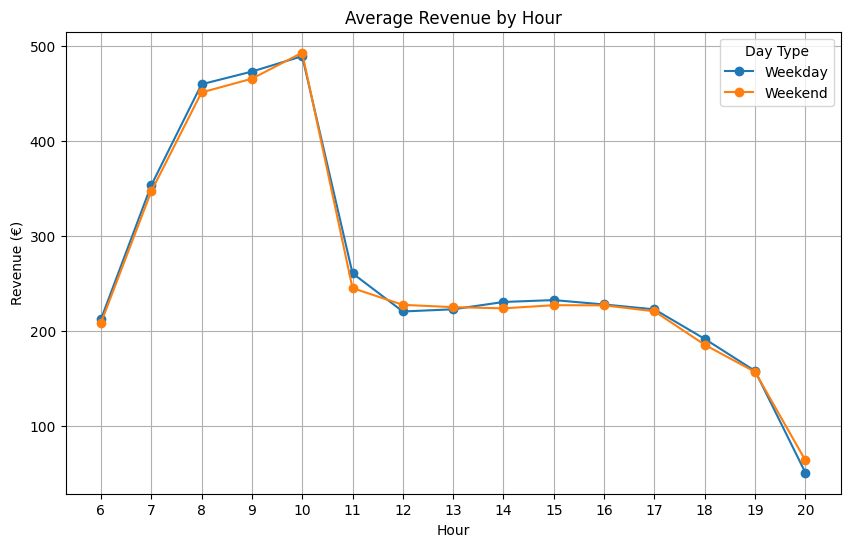

In [4]:
# Aggregate data
daily_revenue = (
    df.groupby(['transaction_date','transaction_hour', 'is_weekend'])['line_revenue']
    .sum()
)
# Normalise data for fair comparison
avg_hourly_revenue = (
    daily_revenue.groupby(['transaction_hour', 'is_weekend'])
    .mean()
    .unstack()
    .sort_index()
)

# Rename columns
avg_hourly_revenue.columns = ['Weekday', 'Weekend']

# Plot hourly revenue for weekdays and weekend.

avg_hourly_revenue.plot(
    kind='line', 
    figsize=(10,6), 
    marker='o'
)

plt.title('Average Revenue by Hour')
plt.xlabel('Hour')
plt.ylabel('Revenue (€)')

plt.grid(True)
plt.xticks(avg_hourly_revenue.index)
plt.legend(title='Day Type')

plt.show()

We can see a similar pattern for both weekdays and weekend days. There is a sharp increase in revenue in the early morning that peaks at 10am, and drops dramatically from 10am-11am. Revenue remains stable from late morning through the afternoon before declining further after 5pm.

##### Plots - Transaction Count


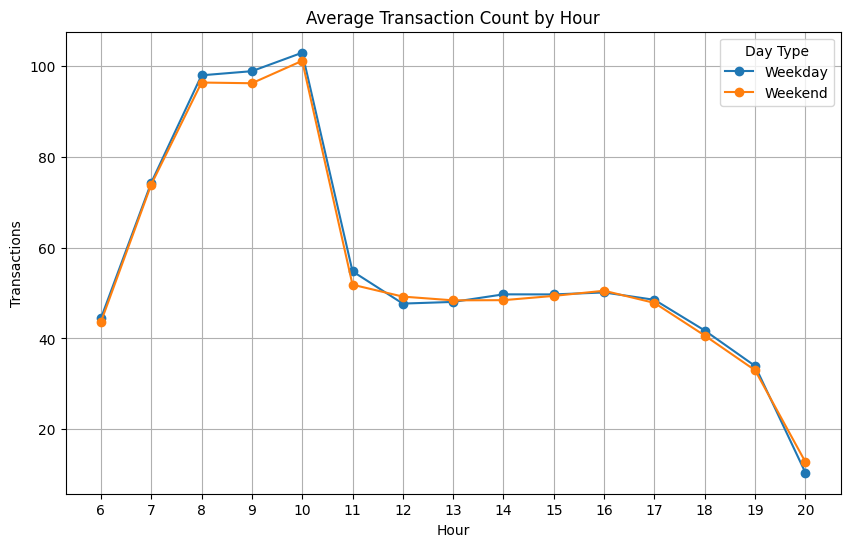

In [5]:
# Aggregate data
daily_transaction_count = (
    df.groupby(['transaction_date', 'transaction_hour', 'is_weekend'])['transaction_id']
    .count()
)
# Normalise data for fair comparison
avg_hourly_transaction_count = (
    daily_transaction_count.groupby(['transaction_hour', 'is_weekend'])
    .mean()
    .unstack()
    .sort_index()
)

# Rename columns
avg_hourly_transaction_count.columns = ['Weekday', 'Weekend']


# Plot transaction count by hour for weekdays and weekend 
avg_hourly_transaction_count.plot(
    kind='line', 
    figsize=(10, 6), 
    marker='o'
)

plt.title('Average Transaction Count by Hour')
plt.xlabel('Hour')
plt.ylabel('Transactions')

plt.xticks(avg_hourly_transaction_count.index)
plt.grid(True)
plt.legend(title='Day Type')

plt.show()

##### Plots - Units Sold

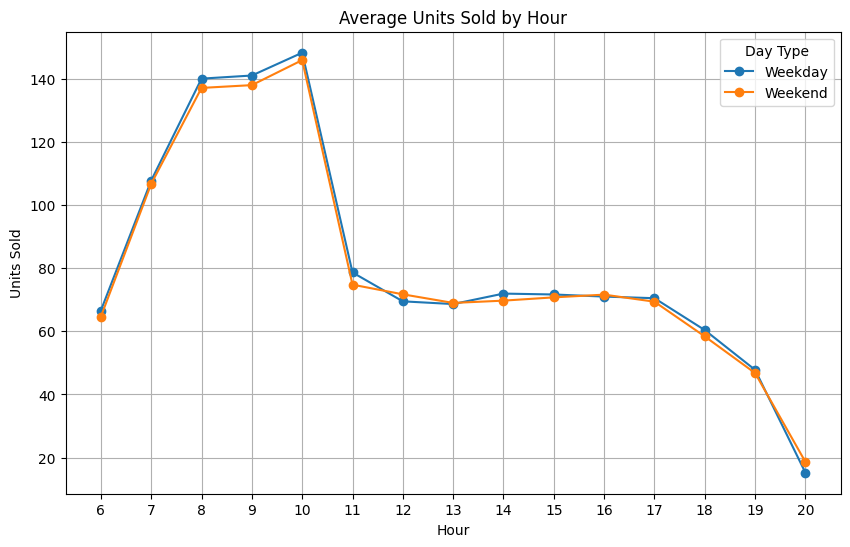

In [6]:
# Aggregate data
daily_units_sold = (
    df.groupby(['transaction_date', 'transaction_hour', 'is_weekend'])['transaction_qty']
    .sum()
)
# Normalise data for fair comparison
avg_hourly_units_sold = (
    daily_units_sold.groupby(['transaction_hour', 'is_weekend'])
    .mean()
    .unstack()
    .sort_index()
)

# Rename columns
avg_hourly_units_sold.columns = ['Weekday', 'Weekend']

# Plot
avg_hourly_units_sold.plot(
    kind='line',
    figsize=(10,6),
    marker='o'
)

plt.title("Average Units Sold by Hour")
plt.xlabel('Hour')
plt.ylabel('Units Sold')

plt.grid(True)
plt.legend(title='Day Type')
plt.xticks(avg_hourly_units_sold.index)

plt.show()


Transaction count by hour follows a similar pattern to revenue by hour, suggesting that peak revenue periods are driven by high transaction volume rather than larger individual purchases. 

Furthermore, we can see that units sold per hour, and transaction count per hour are quite close, supporting the idea that the majority of transactions contain a low number of products. 

Based on these patterns, staffing requirements can be segmented into three operational intensity periods: 
- 7am-10am: High Intensity
- 10am-5pm: Medium Intensity
- 5pm-Close: Low Intensity


### -------------------------------------

### 2. Product Mix
Q: Which products are driving revenue? 
Are there labor intensive products that could be removed from the menu?
Are there any opportunities for bundles or deals? 

To help answer this, we will look at:
- Revenue Concentration
- Volume vs Revenue Comparisons
- Product Category and Time Behaviour

##### Revenue Concentration


In [7]:
# Group total revenue by category.
revenue_by_category = (
    df.groupby(['product_category'])['line_revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns = {
        'product_category': 'Category',
        'line_revenue': 'Revenue'
    })
)


##### Plot - Revenue Concentration

                      Revenue
Category                     
Coffee              269952.45
Tea                 196405.95
Bakery               82315.64
Drinking Chocolate   72416.00
Coffee beans         40085.25
Branded              13607.00
Loose Tea            11213.60
Flavours              8408.80
Packaged Chocolate    4407.64


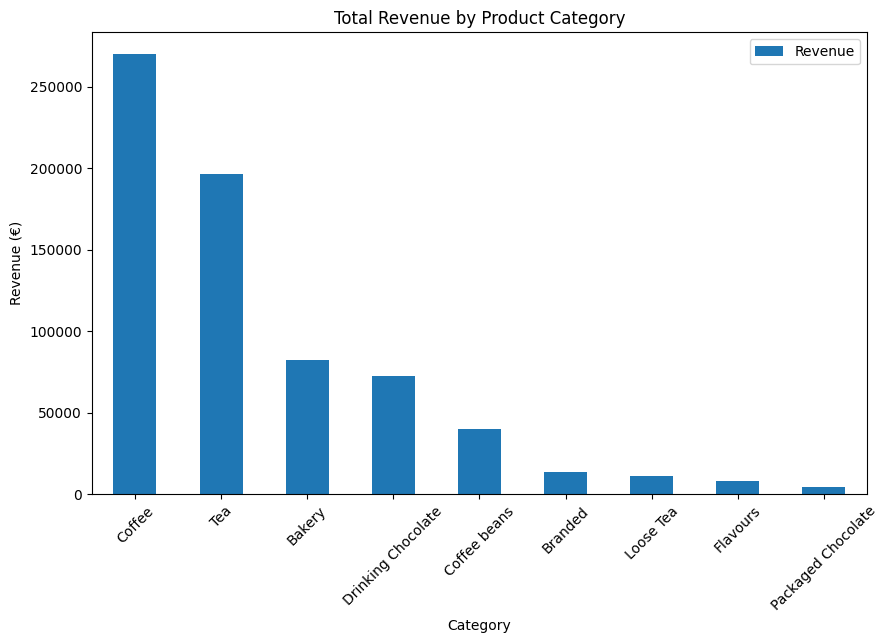

In [8]:
# Set index
revenue_by_category = (
    revenue_by_category
    .set_index('Category')
)

# Check
print(revenue_by_category)

# Plot 
revenue_by_category.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Total Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue (€)')
plt.xticks(rotation=45)

plt.show()

Revenue is heavily concentrated in the Coffee and Tea categories, which together account for the majority of sales revenue, while remaining categories contribute significantly smaller shares of total revenue.

However, before advising any menu decisions for the lower revenue products, additional information such as margins, preparation requirements, and drawing power would be needed. 

##### Volume by Category

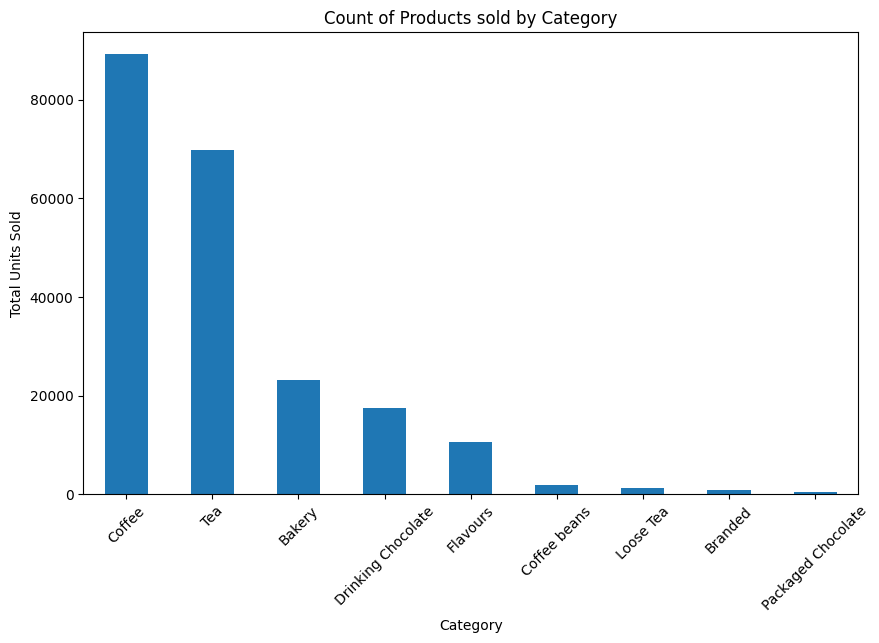

In [9]:
# Aggregte data: total units sold by category
volume_by_category = (
    df.groupby(['product_category'])['transaction_qty']
    .sum()
    .sort_values(ascending=False)
)

# Plot
volume_by_category.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Count of Products sold by Category")
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)

plt.show()


We can see that volume of sales follows a similar trend to revenue with coffee and tea dominating the total units sold.

##### Revenue vs Volume Comparison

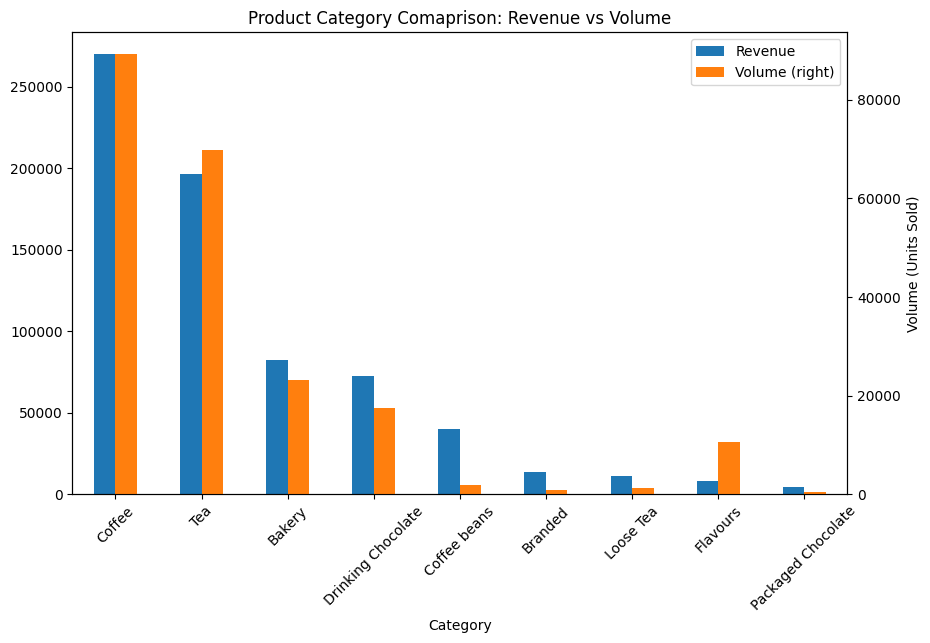

In [10]:
# Combine revenue_by_category(a DataFrame) and 
# volume_by_category(a Series) into a single df to plot.
combined_df = revenue_by_category.merge(
    volume_by_category.to_frame(name='Volume'),
    left_index=True,
    right_index=True
) 
# Add second y-axis label
ax = combined_df.plot.bar(secondary_y='Volume', 
                          rot=45,
                          figsize=(10,6))

ax.set_label('Revenue (€)')
ax.right_ax.set_ylabel('Volume (Units Sold)')

plt.title('Product Category Comaprison: Revenue vs Volume')
plt.xlabel('Category')

plt.show()


We can see that volume of sales follows a similar trend to revenue with two notable exceptions. 

'Flavours' is low revenue but high volume, most likely due to it's use in coffee products.

'Coffee beans' contributes a higher revenue percentage than volume percentage, indicating it is likey to be one of the higher-margin products in the café. 

##### Category Sales Behaviour Over Time
The final analysis for our product mix section is to see if there are any points of interest regarding the timing of product category sales througout the day.

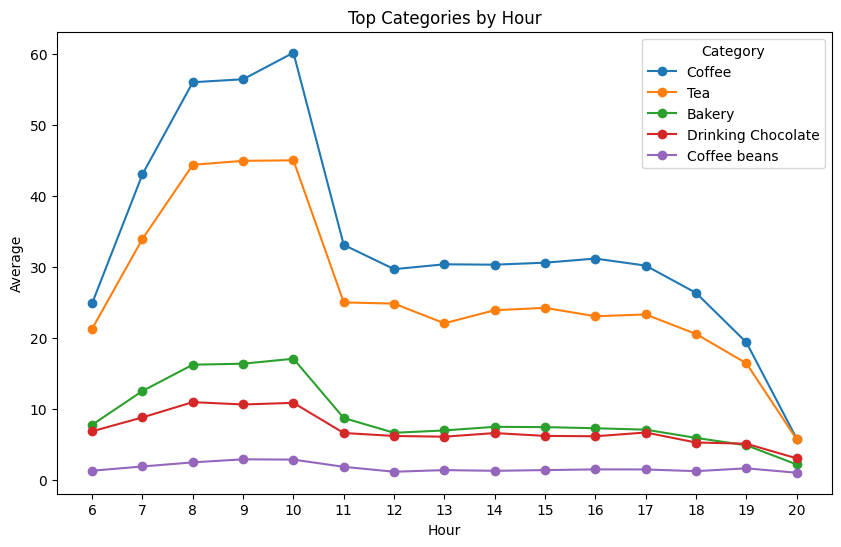

In [11]:
# Find the top performing categories and their behaviour
# over time.

# Aggregate data: total units sold by day.
category_by_day  = (
    df.groupby(['transaction_date', 'transaction_hour', 'product_category'])['transaction_qty']
    .sum()
)
# Normalise data
avg_category_by_hour = (
    category_by_day.groupby(['transaction_hour', 'product_category'])
    .mean()
    .round(2)
    .unstack()
)

# Pick the top 5 product categoies by revenue to plot.
available_cat_count = df['product_category'].nunique()
top_n = min(5, available_cat_count)

top_5_series = (
    df.groupby('product_category')['line_revenue']
    .sum()
    .nlargest(top_n)
)
top_5_categories = top_5_series.index.tolist()

# Plot the category sales over time.
avg_category_by_hour.plot(
    y=top_5_categories,
    kind='line',
    figsize=(10,6),
    marker='o'
)
plt.title("Top Categories by Hour")
plt.xlabel('Hour')
plt.ylabel('Average')
plt.xticks(avg_category_by_hour.index)
plt.legend(title='Category')

plt.show()


Demand patterns are largely aligned with expectations, with Coffee, Tea, and Bakery products showing strong morning peaks. This reflects typical breakfast purchasing behaviour and presents an opportunity for targeted breakfast promotions such as pastry and hot drink bundles.  

### ----------------------------------------

### 3. Operational Planning - Prep

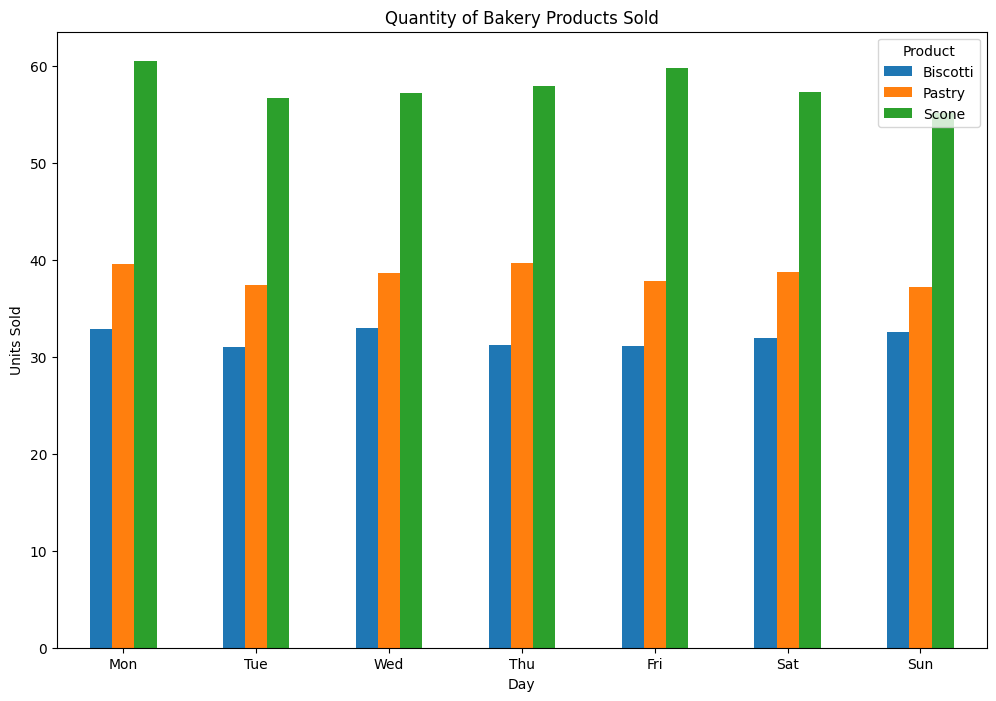

In [12]:
# Filter data for bakery items 
all_day_bakery = (
    df[df['product_category'] == 'Bakery']
)
# Daily totals of bakery products sold
daily_total_units_sold = (
    all_day_bakery.groupby(['transaction_date', 'day_of_week', 'product_type'])['transaction_qty']
    .sum()
)
# Normalise, get daily averages
avg_daily_units_sold = (
    daily_total_units_sold.groupby(['day_of_week', 'product_type'])
    .mean()
    .unstack()
)

# Plot forecast
avg_daily_units_sold.plot(
    kind='bar',
    figsize=(12,8)
)
plt.xlabel('Day')
plt.ylabel('Units Sold')
plt.title('Quantity of Bakery Products Sold')
plt.legend(title='Product')

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.xticks(ticks=avg_daily_units_sold.index, labels=day_names, rotation=0)

plt.show()





The analysis provides a useful baseline for daily bakery demand and could support production planning, inventory management, and staffing decisions. While additional information such as preparation time, waste levels, and sourcing methods would be required for more detailed recommendations, understanding expected daily demand is a practical first step in operational planning.

##### Morning vs Afternoon Comparison

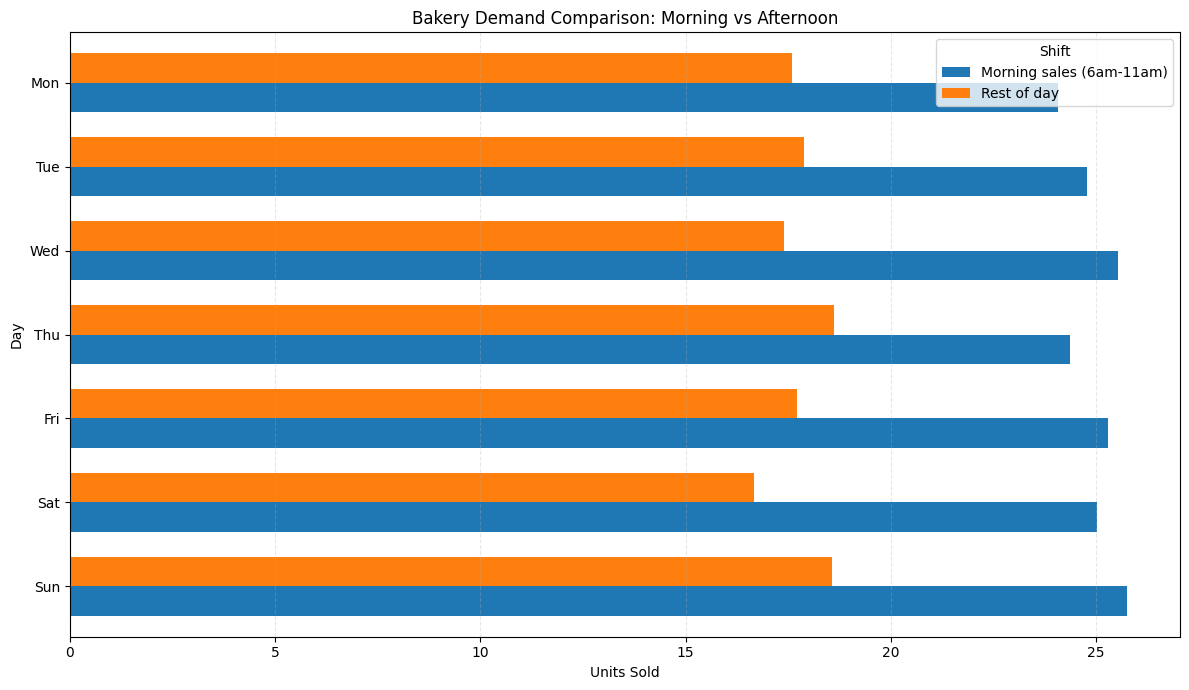

In [27]:
# Filter for bakery sales
bakery_sales = (
    df[df['product_category'] == 'Bakery']
    .copy()
)

# Create shift flag
bakery_sales['shift'] = np.where(
    bakery_sales['transaction_hour'].between(6,11),
    'Morning sales (6am-11am)',
    'Rest of day'
)

# Daily totals by shift
daily_shift_sales = (
    bakery_sales.groupby(
        ['transaction_date',
         'day_of_week',
         'product_type',
         'shift']
         )['transaction_qty']
         .sum()
)
# Normalise to average day
avg_shift_sales = (
    daily_shift_sales.groupby(
        ['day_of_week', 'shift'])
        .mean()
        .unstack()
)


# Create plotting dataframe
comparison_df = avg_shift_sales.copy()

comparison_df = comparison_df.sort_index(ascending=False)

# Reverse index order so Monday is at top of chart
comparison_df = comparison_df.iloc[::-1]

# Plot the stacked barchart
ax = comparison_df.plot(
    kind='barh',
    figsize=(12,7),
    width=0.7,
    color=['#1f77b4', '#ff7f0e']
)

day_names_reversed = ['Sun', 'Sat', 'Fri', 'Thu', 'Wed', 'Tue', 'Mon']
ax.set_yticklabels(day_names_reversed)

plt.xlabel('Units Sold')
plt.ylabel('Day')
plt.title('Bakery Demand Comparison: Morning vs Afternoon')
plt.legend(title='Shift')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

From the above comparison we can see that bakery products sell in a greater volume during the morning rush period. This could translate into two separate baking times each day to meet demand, while preserving freshness of products.